# CS4305 Artificial Intelligence — Lab 12
## Natural Language Processing + Course Review

**What you will learn today**
1. Walk through the **levels of NLP**: tokens → word forms → grammar → meaning
2. **Tag** words with parts of speech and **parse** sentences with a grammar
3. See **ambiguity** with your own eyes
4. Build two NLP applications: **sentiment analysis** and a **help-desk chatbot**
5. Review the whole course with a quiz

**How to use this notebook**
- 📊 **Visual explanation** cells already show a picture. Look at the picture first, then read the code.
- 💻 **Code** cells: click inside and press **Shift + Enter** to run them, from top to bottom.
- 📝 **Lab tasks** are at the end.

In [ ]:
#@title ⚙️ Diagram tools (only needed if you want to redraw the pictures)
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch, Rectangle

PURPLE, ORANGE, TEAL, ROSE, DARK = "#5B2A86", "#FF9F1C", "#1FA898", "#D1495B", "#1A1333"
LIGHT, GREY, WHITE = "#F3EEFA", "#A9A3B8", "#FFFFFF"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 12})

def tree_layout(children, root, gap=1.0):
    """Tidy layout for a tree given as {parent: [children]}."""
    pos, nxt = {}, [0.0]
    def walk(n, d):
        kids = children.get(n, [])
        if not kids:
            pos[n] = (nxt[0], -d); nxt[0] += gap
        else:
            for k in kids: walk(k, d + 1)
            xs = [pos[k][0] for k in kids]
            pos[n] = ((min(xs) + max(xs)) / 2, -d)
    walk(root, 0)
    return pos

def draw_graph(ax, pos, edges, directed=False, weights=None, colors=None, path=None, r=0.28,
               fs=13, label_below=False, badges=None, badge_color=ORANGE, edge_fs=11, names=None):
    """Draw nodes (circles) and edges. path = list of nodes to highlight in orange."""
    colors = colors or {}
    on_path = set()
    if path:
        for a, b in zip(path, path[1:]): on_path |= {(a, b), (b, a)}
    for i, (a, b) in enumerate(edges):
        (x1, y1), (x2, y2) = pos[a], pos[b]
        L = math.hypot(x2 - x1, y2 - y1); ux, uy = (x2 - x1) / L, (y2 - y1) / L
        s, e = (x1 + ux * r, y1 + uy * r), (x2 - ux * r, y2 - uy * r)
        hi = (a, b) in on_path
        ax.annotate("", xy=e, xytext=s, arrowprops=dict(arrowstyle="-|>" if directed else "-",
                    color=ORANGE if hi else GREY, lw=4 if hi else 1.8, shrinkA=0, shrinkB=0,
                    mutation_scale=18), zorder=1)
        if weights:
            w = weights[i]
            ax.text((x1 + x2) / 2, (y1 + y2) / 2, str(w), ha="center", va="center", fontsize=edge_fs,
                    color=DARK, fontweight="bold", zorder=4,
                    bbox=dict(boxstyle="round,pad=0.2", fc=WHITE, ec="none"))
    for n, (x, y) in pos.items():
        c = colors.get(n, PURPLE)
        ax.add_patch(Circle((x, y), r, fc=c, ec=WHITE, lw=2, zorder=3))
        text = (names or {}).get(n, n)
        if label_below:
            ax.text(x, y - r - 0.06, text, ha="center", va="top", fontsize=fs, color=DARK, fontweight="bold", zorder=5)
        else:
            ax.text(x, y, text, ha="center", va="center", fontsize=fs, color=WHITE if c not in (ORANGE, LIGHT, WHITE) else DARK,
                    fontweight="bold", zorder=5)
    if badges:
        for n, t in badges.items():
            x, y = pos[n]
            ax.add_patch(Circle((x + r * 0.95, y + r * 0.95), r * 0.55, fc=badge_color, ec=WHITE, lw=1.5, zorder=6))
            ax.text(x + r * 0.95, y + r * 0.95, str(t), ha="center", va="center", fontsize=fs - 3,
                    color=DARK, fontweight="bold", zorder=7)
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
    m = r * 2.2
    ax.set_xlim(min(xs) - m, max(xs) + m); ax.set_ylim(min(ys) - m - (0.35 if label_below else 0), max(ys) + m)
    ax.set_aspect("equal"); ax.axis("off")

def box(ax, x, y, w, h, text, fc=PURPLE, tc=WHITE, fs=13, bold=True, ec=None, round_=True):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08" if round_ else "square,pad=0",
                                fc=fc, ec=ec or fc, lw=1.5, zorder=2))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, color=tc,
            fontweight="bold" if bold else "normal", zorder=3)

def arrow(ax, x1, y1, x2, y2, color=DARK, lw=2, text=None, fs=11):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, shrinkA=0, shrinkB=0, mutation_scale=16))
    if text:
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.12, text, ha="center", va="bottom", fontsize=fs, color=DARK)

def board(ax, x0, y0, state, size=0.9, title=None, highlight=None, fc=LIGHT):
    """Draw an 8-puzzle board. state = string like '123456780' (0 = blank)."""
    highlight = highlight or {}
    for i, ch in enumerate(state):
        r, c = divmod(i, 3)
        x, y = x0 + c * size, y0 - r * size
        blank = ch == "0"
        ax.add_patch(Rectangle((x, y), size, size, fc=WHITE if blank else highlight.get(ch, fc),
                               ec=DARK, lw=2, zorder=2))
        if not blank:
            ax.text(x + size / 2, y + size / 2, ch, ha="center", va="center", fontsize=20, fontweight="bold",
                    color=WHITE if highlight.get(ch) in (PURPLE, ROSE, TEAL) else DARK, zorder=3)
    if title:
        ax.text(x0 + 1.5 * size, y0 + size + 0.25, title, ha="center", va="bottom", fontsize=14, fontweight="bold", color=DARK)

def finish(fig, title=None):
    if title:
        fig.suptitle(title, fontsize=16, fontweight="bold", color=DARK)
    fig.tight_layout()


# ---- shared data for this lab's diagrams ----
def _text_tree(ax, children, root, labels, colors=None, gap=1.6, w=1.35, h=0.5, fs=12, level_gap=1.1):
    """Draw a tree whose nodes are text boxes. labels: node-id -> text."""
    colors = colors or {}
    pos = tree_layout(children, root, gap=gap)
    pos = {k: (x, y * level_gap) for k, (x, y) in pos.items()}
    for p, ks in children.items():
        for k in ks:
            (x1, y1), (x2, y2) = pos[p], pos[k]
            ax.plot([x1, x2], [y1 - h / 2, y2 + h / 2], color=GREY, lw=1.8, zorder=1)
    for k, (x, y) in pos.items():
        fc = colors.get(k, PURPLE)
        box(ax, x - w / 2, y - h / 2, w, h, labels.get(k, k), fc=fc, tc=DARK if fc in (ORANGE, LIGHT, WHITE) else WHITE, fs=fs)
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
    ax.set_xlim(min(xs) - w, max(xs) + w); ax.set_ylim(min(ys) - h * 1.5, max(ys) + h * 1.5)
    ax.set_aspect("equal"); ax.axis("off")
    return pos

ZOO = [("R1", ["has_hair"], "mammal"), ("R2", ["gives_milk"], "mammal"), ("R3", ["has_feathers"], "bird"),
       ("R4", ["mammal", "eats_meat"], "carnivore"), ("R5", ["carnivore", "tawny", "dark_spots"], "cheetah"),
       ("R6", ["carnivore", "tawny", "black_stripes"], "tiger"), ("R7", ["bird", "swims", "cannot_fly"], "penguin")]

NET_POS = {"Animal": (3.5, 4), "Bird": (1.5, 2.4), "Mammal": (5.5, 2.4), "Canary": (0.3, 0.8), "Penguin": (2.7, 0.8),
           "Cow": (5.5, 0.8), "Tweety": (0.3, -0.8), "fly": (-1.2, 2.4), "feathers": (0.4, 3.7), "breathe": (6.9, 4.4),
           "milk": (7.4, 0.8), "yellow": (-1.4, 0.2)}

NET_EDGES = [("Bird", "Animal", "is-a"), ("Mammal", "Animal", "is-a"), ("Canary", "Bird", "is-a"), ("Penguin", "Bird", "is-a"),
             ("Cow", "Mammal", "is-a"), ("Tweety", "Canary", "instance"), ("Bird", "fly", "can"), ("Bird", "feathers", "has"),
             ("Animal", "breathe", "can"), ("Cow", "milk", "gives"), ("Canary", "yellow", "colour")]

def _net(ax, path=None, exception=True):
    concept = {"Animal", "Bird", "Mammal", "Canary", "Penguin", "Cow", "Tweety"}
    on = set(zip(path, path[1:])) if path else set()
    for a, b, lab in NET_EDGES:
        (x1, y1), (x2, y2) = NET_POS[a], NET_POS[b]
        hi = (a, b) in on
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="-|>", lw=4 if hi else 1.8,
                    color=ORANGE if hi else GREY, shrinkA=22, shrinkB=22, mutation_scale=16))
        ax.text((x1 + x2) / 2, (y1 + y2) / 2, lab, fontsize=10.5, ha="center", va="center", color=DARK,
                bbox=dict(boxstyle="round,pad=0.15", fc=WHITE, ec="none"))
    if exception:
        (x1, y1), (x2, y2) = NET_POS["Penguin"], NET_POS["fly"]
        ax.annotate("", xy=(x2 + 0.3, y2 - 0.2), xytext=(x1 - 0.3, y1 + 0.1), arrowprops=dict(arrowstyle="-|>", lw=2, color=ROSE, ls="--",
                    connectionstyle="arc3,rad=-0.25", shrinkA=14, shrinkB=14))
        ax.text(0.2, 1.55, "can: NO", fontsize=10.5, color=ROSE, fontweight="bold")
    for n_, (x, y) in NET_POS.items():
        if n_ in concept:
            c = ORANGE if n_ == "Tweety" else PURPLE
            box(ax, x - 0.62, y - 0.28, 1.24, 0.56, n_, fc=c, tc=DARK if c == ORANGE else WHITE, fs=11.5)
        else:
            box(ax, x - 0.55, y - 0.25, 1.1, 0.5, n_, fc=LIGHT, tc=DARK, fs=11, bold=False)
    ax.set_xlim(-2.1, 8.1); ax.set_ylim(-1.3, 4.9); ax.set_aspect("equal"); ax.axis("off")
print('Diagram tools ready')

---
## Part 0: Get the language data

In [ ]:
# ===== Download the small language data files NLTK needs (run once) =====
import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
print("NLTK ready")

---
## Part 1: The levels of NLP

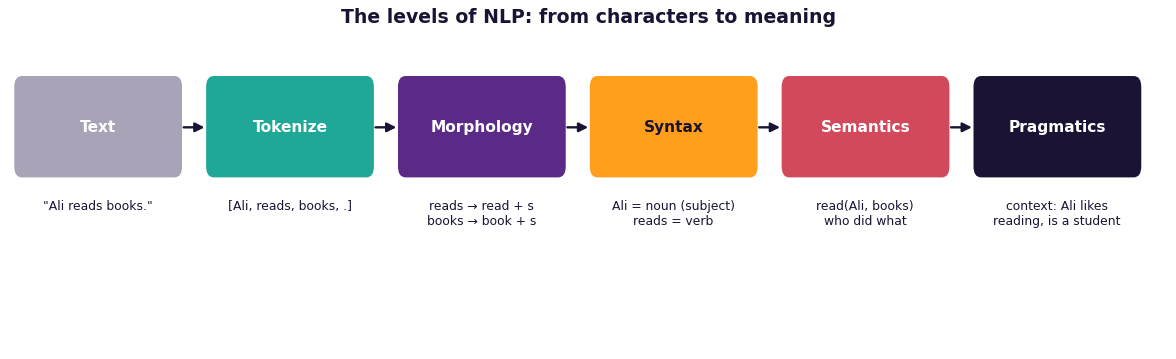

In [ ]:
#@title 📊 Visual explanation: from text to meaning
def fig_nlp_pipeline():
    fig, ax = plt.subplots(figsize=(14, 4.3))
    steps = [("Text", "\"Ali reads books.\""), ("Tokenize", "[Ali, reads, books, .]"), ("Morphology", "reads → read + s\nbooks → book + s"),
             ("Syntax", "Ali = noun (subject)\nreads = verb"), ("Semantics", "read(Ali, books)\nwho did what"), ("Pragmatics", "context: Ali likes\nreading, is a student")]
    cols = [GREY, TEAL, PURPLE, ORANGE, ROSE, DARK]
    for i, ((t, d), c) in enumerate(zip(steps, cols)):
        x = 0.1 + i * 2.3
        box(ax, x, 1.8, 1.95, 0.75, t, fc=c, tc=DARK if c == ORANGE else WHITE, fs=13)
        ax.text(x + 0.97, 1.6, d, ha="center", va="top", fontsize=10.5, color=DARK)
        if i < 5: arrow(ax, x + 2.0, 2.17, x + 2.25, 2.17)
    ax.set_xlim(0, 13.9); ax.set_ylim(0.4, 2.8); ax.axis("off")
    finish(fig, "The levels of NLP: from characters to meaning")
    return fig

fig_nlp_pipeline()
plt.show()

### Tokenization
Splitting text into sentences and words sounds easy, but full stops, abbreviations and short forms make it tricky.

In [ ]:
# ===== Level 1: split text into sentences and words (tokens) =====
from nltk.tokenize import sent_tokenize, word_tokenize
text = "Dr. Ahmed teaches AI at our university. Students love his classes! Don't you?"
print("Sentences:", sent_tokenize(text))
print("Words    :", word_tokenize(text))
print("\nNotice: 'Dr.' did not end the sentence, and \"Don't\" became 'Do' + \"n't\".")

### Morphology: stems and lemmas
- **Stemming** chops the end off a word (fast, sometimes ugly: *studies → studi*)
- **Lemmatization** uses a dictionary to find the real base word (*better → good*)

In [ ]:
# ===== Level 2 (morphology): stems vs lemmas =====
from nltk.stem import PorterStemmer, WordNetLemmatizer
stem, lemma = PorterStemmer(), WordNetLemmatizer()
words = [("studies", "n"), ("studying", "v"), ("better", "a"), ("ran", "v"), ("universities", "n"), ("feet", "n")]
print(f"{'word':14s} {'stem (chop)':14s} lemma (dictionary form)")
for w, t in words:
    print(f"{w:14s} {stem.stem(w):14s} {lemma.lemmatize(w, t)}")

---
## Part 2: Syntax — the grammar of a sentence
**Part-of-speech tagging** labels every word as noun, verb, adjective …

In [ ]:
# ===== Level 3 (syntax): part-of-speech tagging =====
from nltk import pos_tag
TAGS = {"NN": "noun", "NNS": "plural noun", "NNP": "proper noun", "VB": "verb", "VBZ": "verb (he/she)",
        "VBD": "verb (past)", "VBP": "verb", "VBG": "verb -ing", "DT": "determiner", "JJ": "adjective",
        "IN": "preposition", "PRP": "pronoun", "RB": "adverb", "PRP$": "possessive", ".": "punctuation"}
sentence = "Sara quickly solved the difficult AI assignment in the lab."
for word, tag in pos_tag(word_tokenize(sentence)):
    print(f"{word:12s} {tag:5s} {TAGS.get(tag, '')}")

A **grammar** says how words combine: a sentence (S) is a noun phrase (NP) followed by a verb phrase (VP). A **parser** uses the grammar to build a **parse tree**.

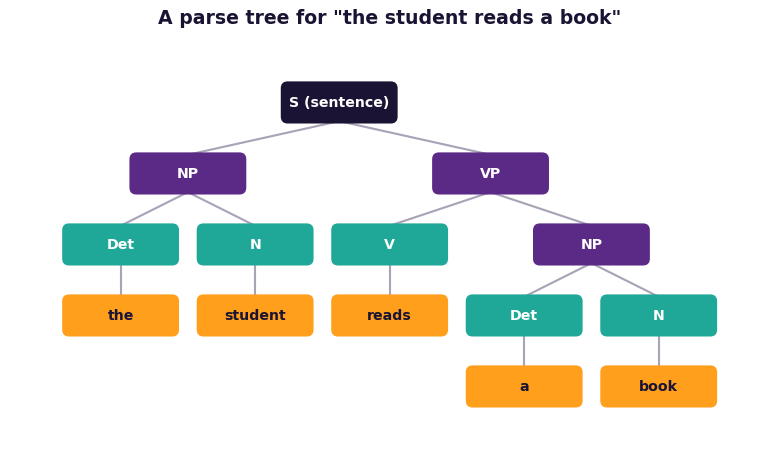

In [ ]:
#@title 📊 Visual explanation: a parse tree
def fig_parse_tree():
    children = {"S": ["NP", "VP"], "NP": ["Det", "N"], "VP": ["V", "NP2"], "NP2": ["Det2", "N2"],
                "Det": ["w1"], "N": ["w2"], "V": ["w3"], "Det2": ["w4"], "N2": ["w5"]}
    labels = {"S": "S (sentence)", "NP": "NP", "VP": "VP", "NP2": "NP", "Det": "Det", "N": "N", "V": "V", "Det2": "Det", "N2": "N",
              "w1": "the", "w2": "student", "w3": "reads", "w4": "a", "w5": "book"}
    colors = {k: (ORANGE if k.startswith("w") else DARK if k == "S" else PURPLE if k in ("NP", "VP", "NP2") else TEAL) for k in labels}
    fig, ax = plt.subplots(figsize=(12, 5.4))
    _text_tree(ax, children, "S", labels, colors, gap=1.8, w=1.5, h=0.5, fs=12, level_gap=0.95)
    finish(fig, "A parse tree for \"the student reads a book\"")
    return fig

fig_parse_tree()
plt.show()

In [ ]:
# ===== Level 3 (syntax): a grammar and a parse tree =====
grammar = nltk.CFG.fromstring("""
  S   -> NP VP
  NP  -> Det N | Name
  VP  -> V NP
  Det -> 'the' | 'a'
  N   -> 'student' | 'book' | 'teacher'
  Name -> 'Ali' | 'Sara'
  V   -> 'reads' | 'helps' | 'likes'
""")
parser = nltk.ChartParser(grammar)
for sent in ["the student reads a book", "Sara helps the teacher"]:
    for tree in parser.parse(sent.split()):
        print(sent); tree.pretty_print()

In [ ]:
# ===== The grammar also tells us what is NOT a correct sentence =====
for sent in ["reads the student a book", "a teacher likes Ali"]:
    trees = list(parser.parse(sent.split()))
    print(f"'{sent}' →", "grammatical ✓" if trees else "NOT grammatical ✗")

---
## Part 3: Ambiguity
Humans use common sense to choose the right meaning. A computer sees **two valid trees**.

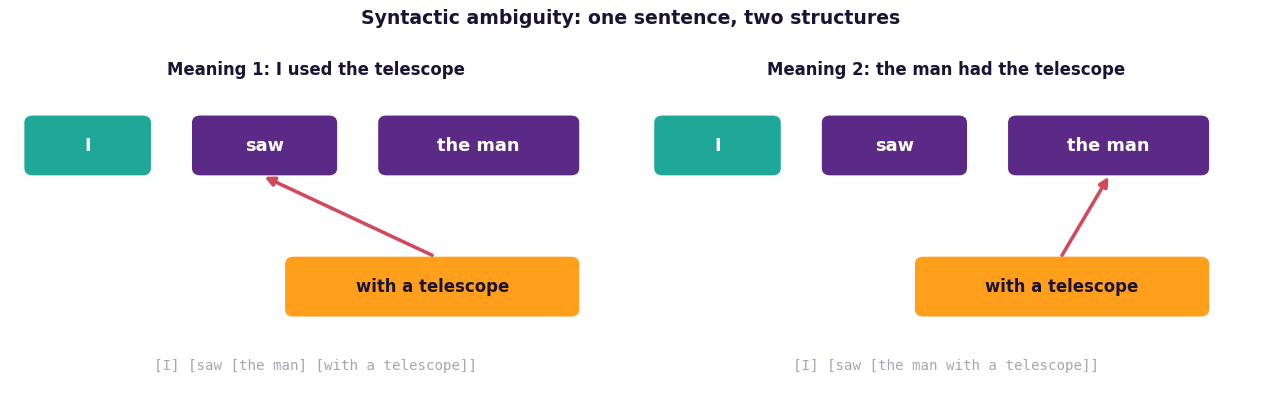

In [ ]:
#@title 📊 Visual explanation: who has the telescope?
def fig_ambiguity():
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
    for ax, (title, desc, attach) in zip(axes, [("Meaning 1: I used the telescope", "[I] [saw [the man] [with a telescope]]", "saw"),
                                                  ("Meaning 2: the man had the telescope", "[I] [saw [the man with a telescope]]", "man")]):
        box(ax, 0.2, 2.3, 1.3, 0.7, "I", fc=TEAL, fs=15)
        box(ax, 2.0, 2.3, 1.5, 0.7, "saw", fc=PURPLE, fs=15)
        box(ax, 4.0, 2.3, 2.1, 0.7, "the man", fc=PURPLE, fs=15)
        box(ax, 3.0, 0.5, 3.1, 0.7, "with a telescope", fc=ORANGE, tc=DARK, fs=14)
        tx = 2.75 if attach == "saw" else 5.05
        arrow(ax, 4.55, 1.25, tx, 2.25, color=ROSE, lw=3)
        ax.text(3.3, 3.55, title, ha="center", fontsize=14, fontweight="bold", color=DARK)
        ax.text(3.3, -0.2, desc, ha="center", fontsize=12, color=GREY, family="monospace")
        ax.set_xlim(0, 6.6); ax.set_ylim(-0.5, 3.9); ax.axis("off")
    finish(fig, "Syntactic ambiguity: one sentence, two structures")
    return fig

fig_ambiguity()
plt.show()

In [ ]:
# ===== Ambiguity: one sentence, two parse trees =====
grammar2 = nltk.CFG.fromstring("""
  S  -> NP VP
  NP -> 'I' | Det N | NP PP
  VP -> V NP | VP PP
  PP -> P NP
  Det -> 'the' | 'a'
  N  -> 'man' | 'telescope'
  V  -> 'saw'
  P  -> 'with'
""")
trees = list(nltk.ChartParser(grammar2).parse("I saw the man with a telescope".split()))
print("Number of parse trees:", len(trees))
for i, t in enumerate(trees, 1):
    print(f"\nMeaning {i}:"); t.pretty_print()

---
## Part 4: NLP applications
### Sentiment analysis with machine learning
The computer learns which words are positive or negative from labelled examples (a **bag of words** + Naive Bayes).

In [ ]:
# ===== An application: learning sentiment from examples (Machine Learning + NLP) =====
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
reviews = ["the lectures are excellent and clear", "great teacher very helpful", "I love the lab tasks",
           "the course is interesting and useful", "amazing examples easy to understand", "very good slides",
           "the class is boring", "too difficult and confusing", "I hate the long assignments",
           "the lab was slow and useless", "bad examples not clear", "very poor explanation"]
labels = ["pos"] * 6 + ["neg"] * 6
vec = CountVectorizer()
X = vec.fit_transform(reviews)                 # turn words into counts ("bag of words")
model = MultinomialNB().fit(X, labels)
for r in ["the teacher is excellent", "the assignments are confusing", "useful and clear lab"]:
    print(f"{r:32s} → {model.predict(vec.transform([r]))[0]}")

### A rule-based chatbot
Like ELIZA from Lecture 1, this bot matches **keywords** (patterns) and replies. Modern chatbots (LLMs) learn from huge amounts of text instead.

In [ ]:
# ===== An application: a rule-based university help-desk chatbot =====
import re
INTENTS = [
    (r"\b(hi|hello|salam|assalam)\b",       "Wa alaikum salam! How can I help you?"),
    (r"\b(fee|fees|challan)\b",             "Fee challans are available on the student portal before the 10th of each month."),
    (r"\b(exam|exams|datesheet|date sheet)\b", "The date sheet is posted on the notice board two weeks before exams."),
    (r"\b(library|books?)\b",               "The library is open 8 am to 8 pm, Monday to Saturday."),
    (r"\b(ai|cs4305)\b",                     "CS4305 Artificial Intelligence is a 3 credit hour course."),
    (r"\b(bye|thanks|thank you)\b",          "You're welcome. Good luck with your studies!"),
]
def reply(message):
    m = message.lower()
    for pattern, answer in INTENTS:
        if re.search(pattern, m):
            return answer
    return "Sorry, I don't understand. Please contact the admin office."

for msg in ["Assalam o alaikum", "When will the date sheet come?", "Where do I get my fee challan?",
            "Is the library open on Sunday?", "What is the weather today?", "thanks!"]:
    print(f"You: {msg}\nBot: {reply(msg)}\n")

In [ ]:
# ===== Chat with the bot yourself (type 'bye' to stop) =====
# Remove the # signs below and run the cell:
# while True:
#     msg = input("You: ")
#     print("Bot:", reply(msg))
#     if "bye" in msg.lower(): break

---
## Part 5: Course review

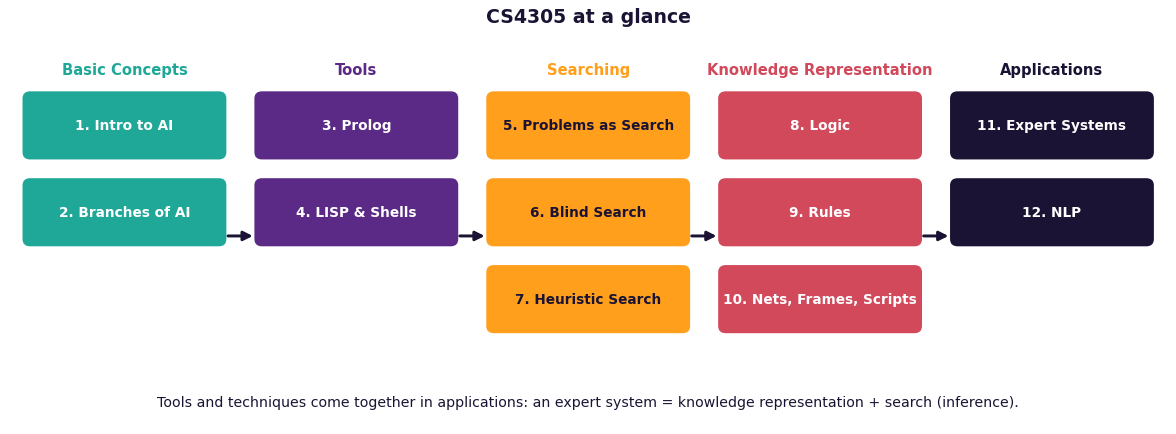

In [ ]:
#@title 📊 Visual explanation: the whole course on one page
def fig_course_map():
    fig, ax = plt.subplots(figsize=(14, 5.2))
    groups = [("Basic Concepts", ["1. Intro to AI", "2. Branches of AI"], TEAL), ("Tools", ["3. Prolog", "4. LISP & Shells"], PURPLE),
              ("Searching", ["5. Problems as Search", "6. Blind Search", "7. Heuristic Search"], ORANGE),
              ("Knowledge Representation", ["8. Logic", "9. Rules", "10. Nets, Frames, Scripts"], ROSE),
              ("Applications", ["11. Expert Systems", "12. NLP"], DARK)]
    for i, (g, items, c) in enumerate(groups):
        x = 0.2 + i * 2.8
        ax.text(x + 1.2, 4.55, g, ha="center", fontsize=12.5, fontweight="bold", color=c if c != DARK else DARK)
        for j, it in enumerate(items):
            box(ax, x, 3.5 - j * 1.1, 2.4, 0.8, it, fc=c, tc=DARK if c == ORANGE else WHITE, fs=11.5)
        if i < 4: arrow(ax, x + 2.45, 2.5, x + 2.75, 2.5, lw=2.5)
    ax.text(7.0, 0.35, "Tools and techniques come together in applications: an expert system = knowledge representation + search (inference).",
            ha="center", fontsize=12, color=DARK)
    ax.set_xlim(0, 14); ax.set_ylim(0.1, 4.9); ax.axis("off")
    finish(fig, "CS4305 at a glance")
    return fig

fig_course_map()
plt.show()

In [ ]:
# ===== Course review quiz (answers are checked automatically) =====
QUIZ = [
    ("Who coined the term 'Artificial Intelligence' in 1956?", ["Alan Turing", "John McCarthy", "Elaine Rich"], 1),
    ("Which language is based on facts, rules and queries?", ["LISP", "Python", "Prolog"], 2),
    ("Which search uses a QUEUE?", ["BFS", "DFS", "Hill climbing"], 0),
    ("A* orders nodes by:", ["h(n)", "g(n)", "g(n) + h(n)"], 2),
    ("An admissible heuristic must never:", ["underestimate", "overestimate", "equal zero"], 1),
    ("'Tweety → Canary → Bird → can fly' is an example of:", ["inheritance", "backtracking", "resolution"], 0),
    ("Data-driven reasoning from facts to conclusions is:", ["backward chaining", "forward chaining", "minimax"], 1),
    ("'I saw the man with a telescope' shows:", ["ambiguity", "stemming", "tokenization"], 0),
]
def run_quiz(my_answers=None):
    score = 0
    for i, (q, options, correct) in enumerate(QUIZ):
        print(f"Q{i+1}. {q}")
        for j, o in enumerate(options):
            print(f"     {j + 1}) {o}")
        choice = my_answers[i] if my_answers else int(input("Your answer (1/2/3): ")) - 1
        ok = choice == correct
        score += ok
        print("   ", "✓ correct" if ok else f"✗ answer: {options[correct]}", "\n")
    print(f"Score: {score} / {len(QUIZ)}")

run_quiz(my_answers=[1, 2, 0, 2, 1, 0, 1, 0])   # demo with all-correct answers
# To take the quiz yourself:  run_quiz()

---
## 📝 Lab Tasks
1. Tag the sentence *"The old man the boats."* Is the tagging correct? Why is this sentence hard?
2. Add words and rules to `grammar` so it can parse *"the clever student reads a long book"* (add adjectives: `NP -> Det Adj N`).
3. Add 6 more reviews (3 positive, 3 negative) to the sentiment data and test 3 new sentences.
4. Add 3 new intents to the chatbot (e.g. transport, hostel, scholarship).
5. Take the quiz yourself with `run_quiz()` and write 3 new questions about topics you found difficult.